# Análise Exploratória de Dados — CAGED (Curitiba e RMC)

**Fonte:** Novo CAGED — Ministério do Trabalho e Emprego  
**Objetivo:** Explorar os microdados de movimentação (admissões e desligamentos) da Região Metropolitana de Curitiba, compreendendo distribuições, relações entre variáveis e qualidade dos dados, como subsídio para a etapa de modelagem preditiva da coluna `saldomovimentacao`.

---

**Sumário**
- 1 Importações e Configurações
- 2 Análise Exploratória de Dados
    - 2.1 Carregamento e Visão Geral
    - 2.2 Qualidade dos Dados (nulos, duplicatas, tipos)
    - 2.3 Variável-Alvo: `saldomovimentacao`
    - 2.4 Análise Temporal
    - 2.5 Análise Geográfica (Municípios)
    - 2.6 Análise Setorial (Seção CNAE)
    - 2.7 Análise Demográfica (Sexo, Raça/Cor, Escolaridade, Idade)
    - 2.8 Análise Salarial
    - 2.9 Variáveis de Trabalho (Horas, Tipo de Empregador, Deficiência, etc.)
    - 2.10 Matriz de Correlação
    - 2.11 Análise Bivariada com a Variável-Alvo
    - 2.12 Conclusões e Insights

## 1 Importações e Configurações

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

### Configurações

In [12]:
# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 100,
})

# Configurações do pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.expand_frame_repr", False)

SEED = 42

### Dicionários de domínio
Mapeamentos dos códigos para descrições legíveis, baseados na documentação oficial do CAGED.

In [13]:
MAP_REGIAO = {1: "Norte", 2: "Nordeste", 3: "Sudeste", 4: "Sul", 5: "Centro-Oeste"}

MAP_SEXO = {1: "Masculino", 3: "Feminino", 2: "Ignorado", 0: "?"}

MAP_RACA_COR = {
    1: "Branca", 2: "Preta", 3: "Parda",
    4: "Amarela", 5: "Indígena", 6: "Não informada",
    9: "Não informada", 0: "?",
}

MAP_GRAU_INSTRUCAO = {
    0: "?", 1: "Analfabeto", 2: "Até 5ª inc.", 3: "5ª completa",
    4: "6ª-9ª inc.", 5: "Fund. Completo", 6: "Médio Inc.",
    7: "Médio Completo", 8: "Superior Inc.", 9: "Superior Completo",
    10: "Mestrado", 11: "Doutorado",
}

MAP_SALDO = {1: "Admissão", -1: "Desligamento"}

MAP_TIPO_ESTABELECIMENTO = {0: "?", 1: "CNPJ", 2: "CPF", 3: "CAEPF", 4: "CNO"}

MAP_TIPO_EMPREGADOR = {0: "?", 1: "Pessoa Jurídica", 2: "Pessoa Física", 3: "CEI", 4: "CAEPF"}

MAP_DEFICIENCIA = {
    0: "Sem deficiência", 1: "Física", 2: "Auditiva",
    3: "Visual", 4: "Intelectual", 5: "Múltipla", 9: "Não informado",
}

MAP_TAM_ESTAB = {
    0: "?", 1: "Até 4", 2: "5-9", 3: "10-19",
    4: "20-49", 5: "50-99", 6: "100-249", 7: "250-999",
    8: "1000+", 9: "1000+", 10: "1000+",
}

MAP_SECAO_CNAE = {
    "A": "Agropecuária", "B": "Ind. Extrativas", "C": "Ind. Transformação",
    "D": "Eletricidade/Gás", "E": "Água/Esgoto", "F": "Construção",
    "G": "Comércio", "H": "Transporte", "I": "Alojamento/Alimentação",
    "J": "Informação/Comunicação", "K": "Ativ. Financeiras", "L": "Ativ. Imobiliárias",
    "M": "Ativ. Profissionais", "N": "Ativ. Administrativas", "O": "Adm. Pública",
    "P": "Educação", "Q": "Saúde", "R": "Artes/Cultura",
    "S": "Outros Serviços", "T": "Serv. Domésticos", "U": "Org. Internacionais",
}

MAP_UNID_SALARIO = {1: "Hora", 2: "Dia", 3: "Semana", 4: "Quinzena", 5: "Mensal", 6: "Tarefa", 7: "Outros"}

print("Dicionários carregados.")

Dicionários carregados.


## 2 Análise Exploratória de Dados

## 2. Carregamento e Visão Geral

In [14]:
DATASET_PATH = Path("caged_curitiba_consolidado_train.csv")

df = pd.read_csv(DATASET_PATH, dtype=str)

print(f"Tamanho do Dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

print(f"\nColunas: {list(df.columns)}")

Tamanho do Dataset: 742,427 linhas × 26 colunas

Colunas: ['competenciamov', 'regiao', 'uf', 'municipio', 'secao', 'subclasse', 'saldomovimentacao', 'cbo2002ocupacao', 'categoria', 'graudeinstrucao', 'idade', 'horascontratuais', 'racacor', 'sexo', 'tipoempregador', 'tipoestabelecimento', 'tipodedeficiencia', 'indtrabintermitente', 'indtrabparcial', 'salario', 'tamestabjan', 'indicadoraprendiz', 'origemdainformacao', 'competenciadec', 'unidadesalariocodigo', 'valorsalariofixo']


In [15]:
# Conversão de tipos
int_cols = [
    "competenciamov", "regiao", "uf", "municipio", "saldomovimentacao",
    "cbo2002ocupacao", "categoria", "graudeinstrucao", "idade",
    "racacor", "sexo", "tipoempregador", "tipoestabelecimento",
    "tipodedeficiencia", "indtrabintermitente", "indtrabparcial",
    "tamestabjan", "indicadoraprendiz", "origemdainformacao",
    "competenciadec", "unidadesalariocodigo",
]

float_cols = ["salario", "valorsalariofixo"]

for c in int_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

# horascontratuais pode ter vírgula como separador decimal
df["horascontratuais"] = (
    df["horascontratuais"]
    .str.replace(",", ".", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

for c in float_cols:
    df[c] = (
        df[c]
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

df.head(3)

,competenciamov,regiao,uf,municipio,secao,subclasse,saldomovimentacao,cbo2002ocupacao,categoria,graudeinstrucao,idade,horascontratuais,racacor,sexo,tipoempregador,tipoestabelecimento,tipodedeficiencia,indtrabintermitente,indtrabparcial,salario,tamestabjan,indicadoraprendiz,origemdainformacao,competenciadec,unidadesalariocodigo,valorsalariofixo
0,202301,4,41,410690,S,9420100,1,411010,101,9,28,40.00,1,3,0,1,0,0,0,2935.24,7,0,1,202401,1,5.00
1,202301,4,41,410690,Q,8800600,1,515305,101,9,33,8.00,2,1,0,1,0,0,0,900.00,4,0,1,202401,1,5.00
2,202301,4,41,410690,G,4520005,1,519935,101,7,51,44.00,1,1,0,1,0,0,0,1540.00,3,0,1,202401,1,5.00


In [16]:
df.dtypes

competenciamov            Int64
regiao                    Int64
uf                        Int64
municipio                 Int64
secao                       str
subclasse                   str
saldomovimentacao         Int64
cbo2002ocupacao           Int64
categoria                 Int64
graudeinstrucao           Int64
idade                     Int64
horascontratuais        float64
racacor                   Int64
sexo                      Int64
tipoempregador            Int64
tipoestabelecimento       Int64
tipodedeficiencia         Int64
indtrabintermitente       Int64
indtrabparcial            Int64
salario                 float64
tamestabjan               Int64
indicadoraprendiz         Int64
origemdainformacao        Int64
competenciadec            Int64
unidadesalariocodigo      Int64
valorsalariofixo        float64
dtype: object

In [17]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
competenciamov,742427.00,<NA>,<NA>,<NA>,202458.61,50.43,202301.00,202411.00,202501.00,202511.00,202512.00
regiao,742427.00,<NA>,<NA>,<NA>,4.00,0.00,4.00,4.00,4.00,4.00,4.00
uf,742427.00,<NA>,<NA>,<NA>,41.00,0.00,41.00,41.00,41.00,41.00,41.00
municipio,742427.00,<NA>,<NA>,<NA>,410964.56,642.80,410180.00,410690.00,410690.00,410690.00,412550.00
secao,742427,22,N,224371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subclasse,742427,1037,7820500,73389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saldomovimentacao,742427.00,<NA>,<NA>,<NA>,-0.02,1.00,-1.00,-1.00,-1.00,1.00,1.00
cbo2002ocupacao,742427.00,<NA>,<NA>,<NA>,536699.54,177614.17,10105.00,414140.00,514320.00,716305.00,999999.00
categoria,742427.00,<NA>,<NA>,<NA>,101.89,7.72,101.00,101.00,101.00,101.00,999.00
graudeinstrucao,742427.00,<NA>,<NA>,<NA>,7.52,7.32,1.00,7.00,7.00,7.00,99.00


## 3. Qualidade dos Dados

### 3.1 Valores ausentes

In [18]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumo_nulos = pd.DataFrame({"Ausentes": nulos, "%": nulos_pct}).query("Ausentes > 0").sort_values("%", ascending=False)

if resumo_nulos.empty:
    print("Nenhum valor ausente encontrado.")
else:
    display(resumo_nulos)
    # fig, ax = plt.subplots(figsize=(10, max(3, len(resumo_nulos) * 0.5)))
    # resumo_nulos["%"].plot.barh(ax=ax, color="salmon")
    # ax.set_xlabel("% Ausentes")
    # ax.set_title("Percentual de Valores Ausentes por Coluna")
    # plt.tight_layout()
    # plt.show()

,Ausentes,%
idade,3,0.00


### 3.2 Duplicatas

In [42]:
n_dup = df.duplicated().sum()
print(f"Linhas duplicadas exatas: {n_dup:,} ({n_dup / len(df) * 100:.2f}%)")

Linhas duplicadas exatas: 42,549 (5.73%)


### 3.3 Valores únicos por coluna

In [43]:
unicos = df.nunique().sort_values(ascending=False)
display(unicos.to_frame("n_unicos"))

,n_unicos
salario,60506
cbo2002ocupacao,1843
horascontratuais,1102
subclasse,1037
idade,76
competenciamov,36
secao,22
municipio,16
graudeinstrucao,13
tamestabjan,10


### 3.4 Verificação de valores inesperados em variáveis categóricas

In [19]:
cat_checks = {
    "saldomovimentacao": {1, -1},
    "sexo": {1, 2, 3},
    "racacor": {1, 2, 3, 4, 5, 6, 9},
    "tipoempregador": {0, 1, 2, 3, 4},
    "tipodedeficiencia": {0, 1, 2, 3, 4, 5, 9},
    "indtrabintermitente": {0, 1},
    "indtrabparcial": {0, 1, 9},
    "indicadoraprendiz": {0, 1},
}

for col, esperados in cat_checks.items():
    reais = set(df[col].dropna().unique())
    inesperados = reais - esperados
    if inesperados:
        print(f"⚠ {col}: valores inesperados -> {inesperados}")
    else:
        print(f"✓ {col}: OK")

✓ saldomovimentacao: OK
⚠ sexo: valores inesperados -> {np.int64(9)}
✓ racacor: OK
✓ tipoempregador: OK
⚠ tipodedeficiencia: valores inesperados -> {np.int64(6)}
⚠ indtrabintermitente: valores inesperados -> {np.int64(9)}
✓ indtrabparcial: OK
✓ indicadoraprendiz: OK


## 4. Variável-Alvo: `saldomovimentacao`

O target é binário: **1** (admissão) ou **-1** (desligamento).

Distribuição da variável-alvo:
                   Contagem     %
saldomovimentacao                
Desligamento         378946 51.04
Admissão             363481 48.96


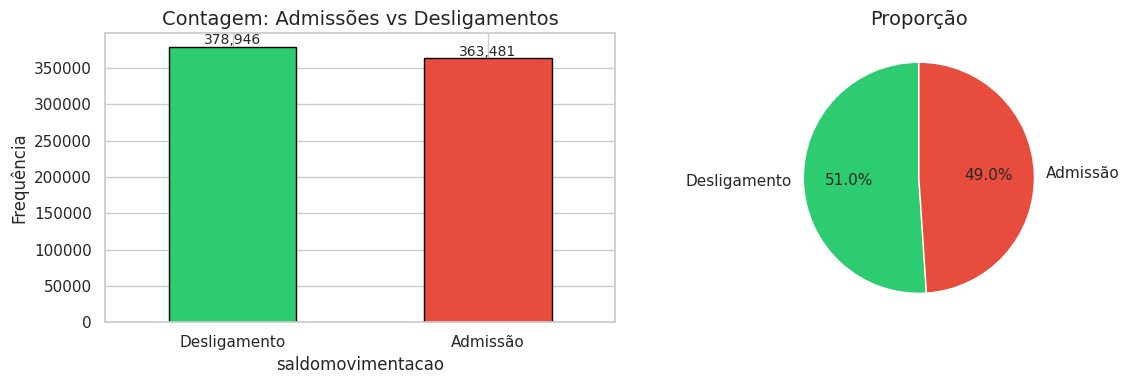


Razão entre classes: 1.04:1


In [45]:
saldo_counts = df["saldomovimentacao"].map(MAP_SALDO).value_counts()
saldo_pct = df["saldomovimentacao"].map(MAP_SALDO).value_counts(normalize=True) * 100

print("Distribuição da variável-alvo:")
print(pd.DataFrame({"Contagem": saldo_counts, "%": saldo_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#2ecc71", "#e74c3c"]
saldo_counts.plot.bar(ax=axes[0], color=colors, edgecolor="black")
axes[0].set_title("Contagem: Admissões vs Desligamentos")
axes[0].set_ylabel("Frequência")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(saldo_counts.values):
    axes[0].text(i, v + len(df) * 0.005, f"{v:,}", ha="center", fontsize=10)

saldo_counts.plot.pie(ax=axes[1], autopct="%1.1f%%", colors=colors,
                      startangle=90, textprops={"fontsize": 11})
axes[1].set_ylabel("")
axes[1].set_title("Proporção")

plt.tight_layout()
plt.show()

ratio = saldo_counts.max() / saldo_counts.min()
print(f"\nRazão entre classes: {ratio:.2f}:1")

## 5. Análise Temporal

In [47]:
# Volume total por competência
vol_mes = df.groupby("competenciamov").size().rename("total_movimentacoes")
print("Volume de movimentações por mês:")
display(vol_mes.to_frame())

print(f"\nMeses com dados: {df['competenciamov'].nunique()}")
print(f"Período: {df['competenciamov'].min()} a {df['competenciamov'].max()}")

Volume de movimentações por mês:


,total_movimentacoes
competenciamov,
202301,52
202302,35
202303,14
202304,11
202305,23
202306,22
202307,15
202308,34
202309,130



Meses com dados: 36
Período: 202301 a 202512


saldomovimentacao,Desligamento,Admissão,Saldo Líquido
competenciamov,,,
202301,11,41,30
202302,2,33,31
202303,8,6,-2
202304,4,7,3
202305,8,15,7
202306,11,11,0
202307,7,8,1
202308,11,23,12
202309,46,84,38


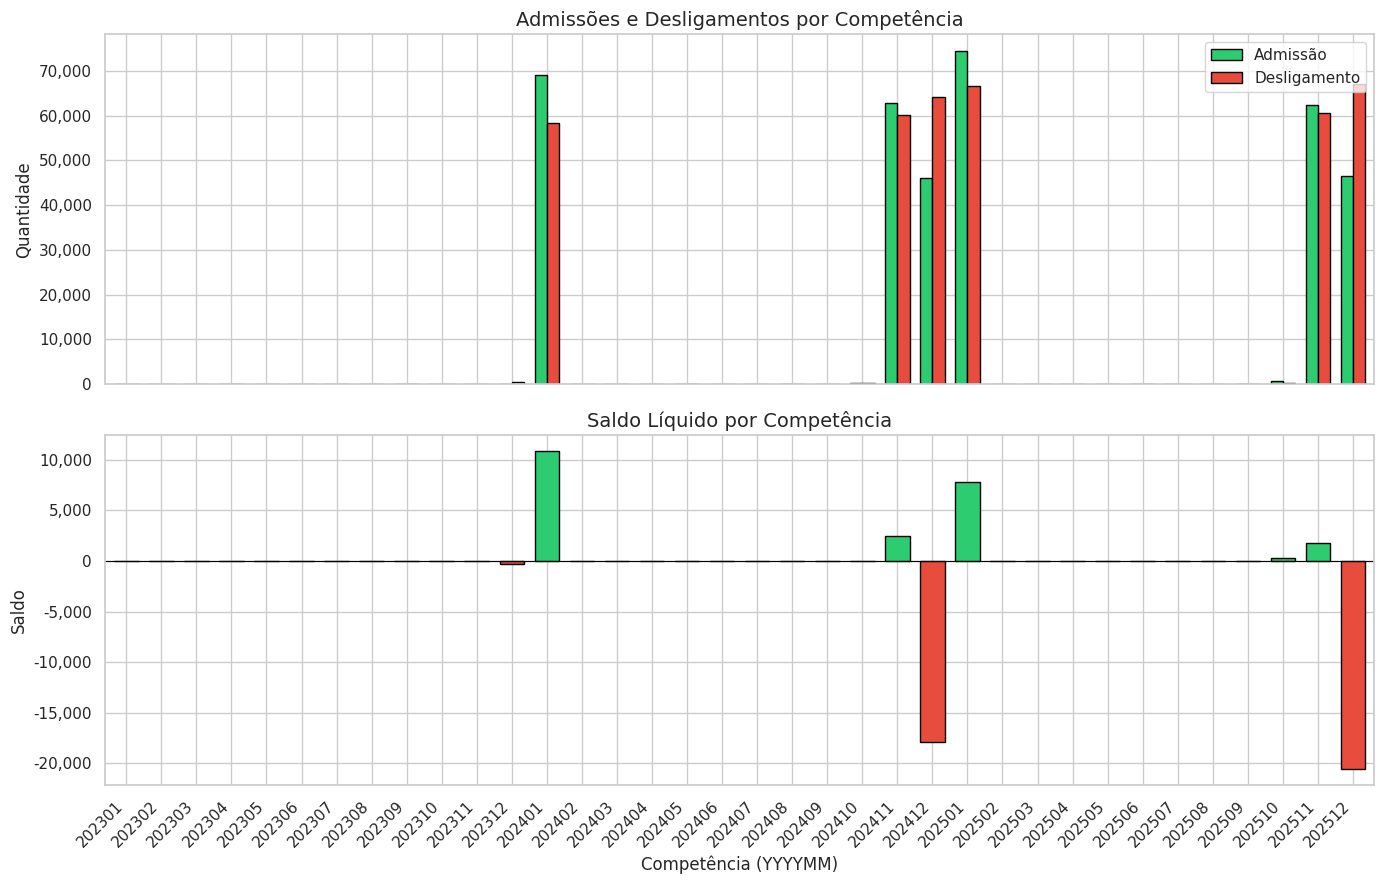

In [46]:
# Movimentações por competência
temp = (
    df.groupby(["competenciamov", "saldomovimentacao"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=MAP_SALDO)
)
temp["Saldo Líquido"] = temp.get("Admissão", 0) - temp.get("Desligamento", 0)

display(temp)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

temp[["Admissão", "Desligamento"]].plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"], edgecolor="black", width=0.7)
axes[0].set_title("Admissões e Desligamentos por Competência")
axes[0].set_ylabel("Quantidade")
axes[0].legend(loc="upper right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

temp["Saldo Líquido"].plot.bar(
    ax=axes[1],
    color=["#2ecc71" if v >= 0 else "#e74c3c" for v in temp["Saldo Líquido"]],
    edgecolor="black", width=0.7,
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Saldo Líquido por Competência")
axes[1].set_ylabel("Saldo")
axes[1].set_xlabel("Competência (YYYYMM)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.1 Identificação dos meses relevantes

Conforme a descrição do trabalho, devem ser usados **novembro, dezembro e janeiro de 2024 e 2025**. Os demais meses existem na base e o professor recomenda entender o porquê e considerá-los com cautela.

In [48]:
# Extrair mês e ano para análise
df["ano"] = df["competenciamov"] // 100
df["mes"] = df["competenciamov"] % 100

meses_relevantes = {11, 12, 1}  # nov, dez, jan
df["mes_relevante"] = df["mes"].isin(meses_relevantes)

print("Distribuição por ano e mês:")
display(
    df.groupby(["ano", "mes"]).size().unstack(fill_value=0)
)

print(f"\nRegistros em meses relevantes (nov/dez/jan): {df['mes_relevante'].sum():,} ({df['mes_relevante'].mean()*100:.1f}%)")
print(f"Registros em outros meses: {(~df['mes_relevante']).sum():,} ({(~df['mes_relevante']).mean()*100:.1f}%)")

Distribuição por ano e mês:


mes,1,2,3,4,5,6,7,8,9,10,11,12
ano,,,,,,,,,,,,
2023,52,35,14,11,23,22,15,34,130,61,138,567
2024,127604,85,41,41,34,47,67,96,145,475,123069,110298
2025,141232,75,34,68,43,54,63,86,126,908,123012,113622



Registros em meses relevantes (nov/dez/jan): 739,594 (99.6%)
Registros em outros meses: 2,833 (0.4%)


## 6. Análise Geográfica (Municípios)

Total de municípios distintos: 16

Top 15 municípios por volume de movimentação:


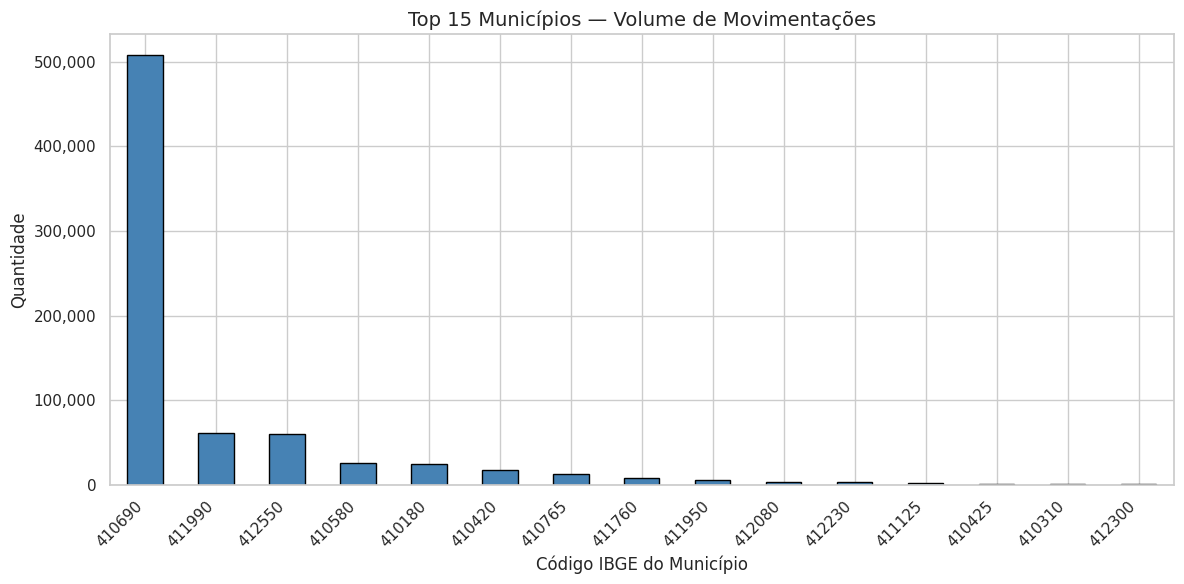


Curitiba (410690) representa 68.4% de todas as movimentações.


In [16]:
mun_counts = df["municipio"].value_counts()

print(f"Total de municípios distintos: {mun_counts.shape[0]}")
print(f"\nTop 15 municípios por volume de movimentação:")

top_mun = mun_counts.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_mun.plot.bar(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Top 15 Municípios — Volume de Movimentações")
ax.set_xlabel("Código IBGE do Município")
ax.set_ylabel("Quantidade")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Concentração
curitiba_share = mun_counts.get(410690, 0) / mun_counts.sum() * 100
print(f"\nCuritiba (410690) representa {curitiba_share:.1f}% de todas as movimentações.")

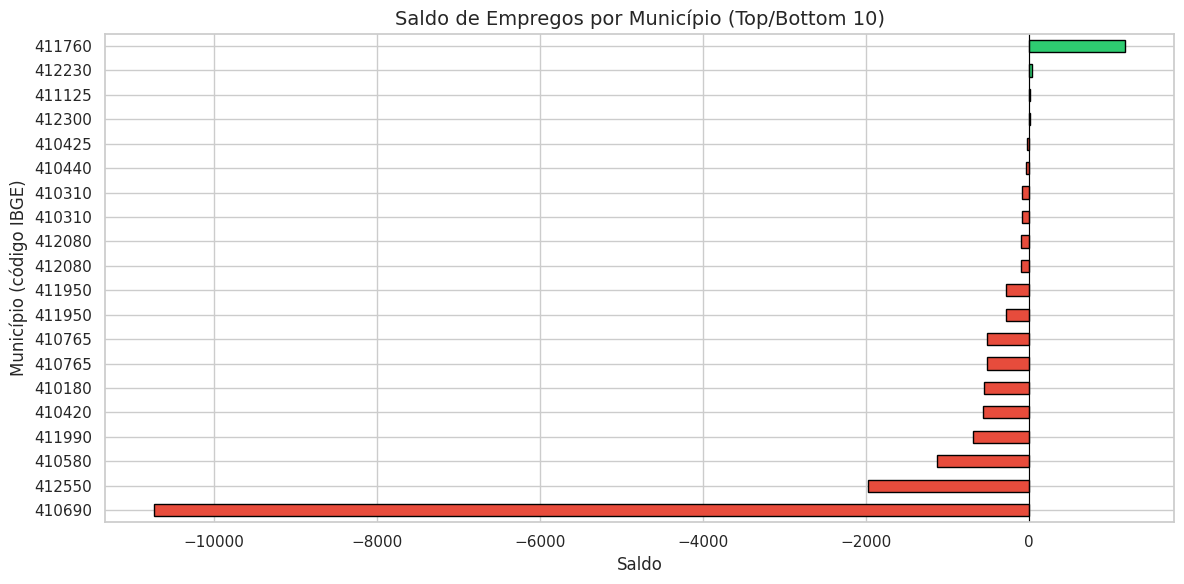

In [17]:
# Saldo por município (top e bottom)
saldo_mun = df.groupby("municipio")["saldomovimentacao"].sum().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
top_bottom = pd.concat([saldo_mun.head(10), saldo_mun.tail(10)]).sort_values()
cores = ["#e74c3c" if v < 0 else "#2ecc71" for v in top_bottom.values]
top_bottom.plot.barh(ax=ax, color=cores, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Saldo de Empregos por Município (Top/Bottom 10)")
ax.set_xlabel("Saldo")
ax.set_ylabel("Município (código IBGE)")
plt.tight_layout()
plt.show()

## 7. Análise Setorial (Seção CNAE)

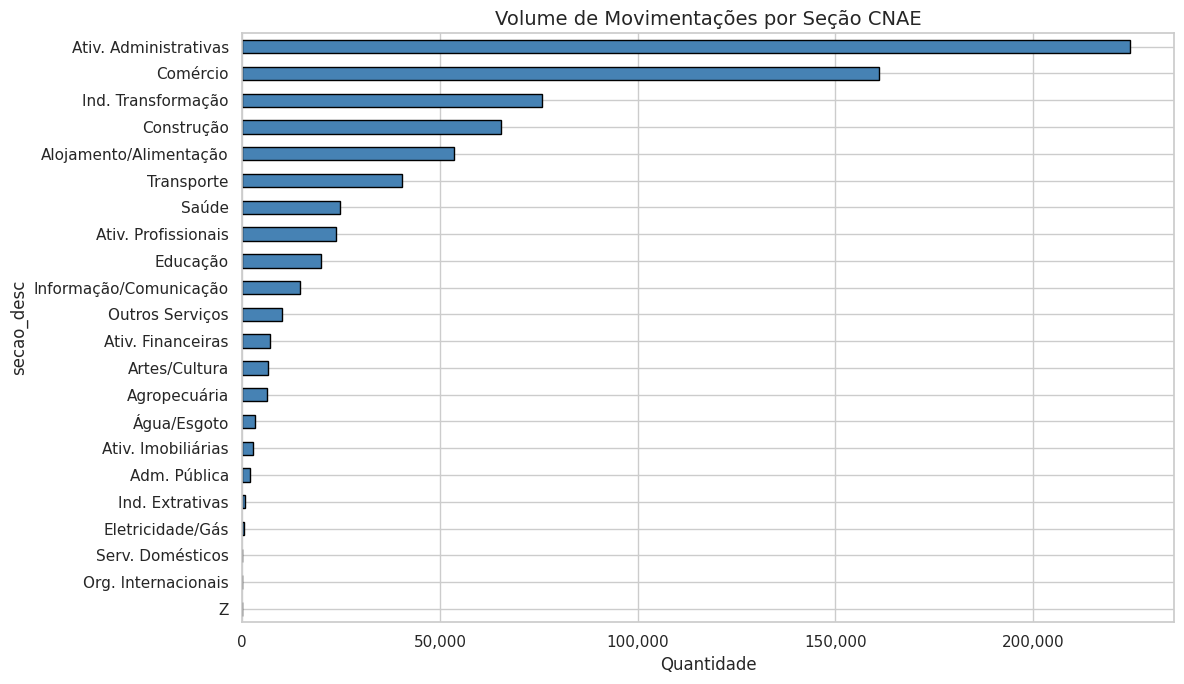

In [18]:
df["secao_desc"] = df["secao"].map(MAP_SECAO_CNAE).fillna(df["secao"])

secao_counts = df["secao_desc"].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))
secao_counts.sort_values().plot.barh(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Volume de Movimentações por Seção CNAE")
ax.set_xlabel("Quantidade")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

,Saldo,Total Movimentações,Taxa Líquida
secao_desc,,,
Educação,-4416,19832,-22.27
Construção,-4044,65388,-6.18
Comércio,-2530,160954,-1.57
Ind. Transformação,-1902,75846,-2.51
Transporte,-1662,40292,-4.12
Alojamento/Alimentação,-1598,53588,-2.98
Outros Serviços,-877,10093,-8.69
Adm. Pública,-315,1963,-16.05
Ativ. Financeiras,-269,6949,-3.87


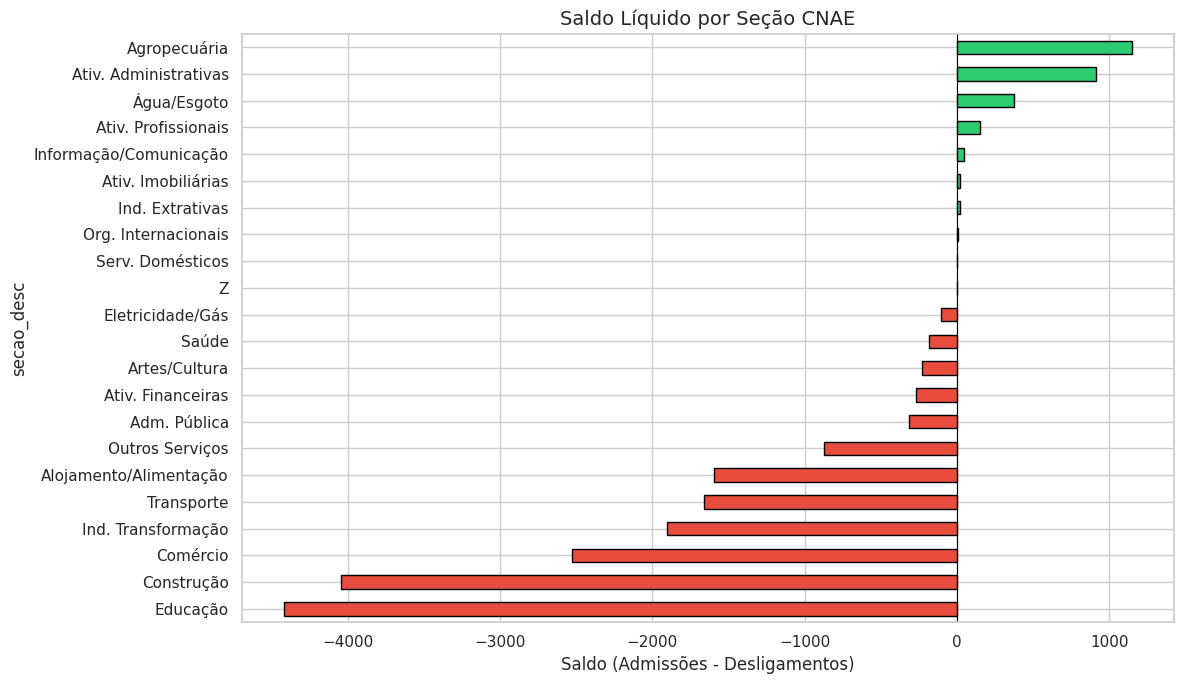

In [19]:
# Saldo por seção CNAE
saldo_secao = df.groupby("secao_desc")["saldomovimentacao"].agg(["sum", "count", "mean"])
saldo_secao.columns = ["Saldo", "Total Movimentações", "Taxa Líquida"]
saldo_secao["Taxa Líquida"] = (saldo_secao["Taxa Líquida"] * 100).round(2)
saldo_secao = saldo_secao.sort_values("Saldo")

display(saldo_secao)

fig, ax = plt.subplots(figsize=(12, 7))
cores = ["#e74c3c" if v < 0 else "#2ecc71" for v in saldo_secao["Saldo"]]
saldo_secao["Saldo"].plot.barh(ax=ax, color=cores, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Saldo Líquido por Seção CNAE")
ax.set_xlabel("Saldo (Admissões - Desligamentos)")
plt.tight_layout()
plt.show()

## 8. Análise Demográfica

### 8.1 Sexo

saldomovimentacao,Desligamento,Admissão,Saldo
sexo_desc,,,
?,1,3,2
Feminino,175559,165045,-10514
Masculino,203386,198433,-4953


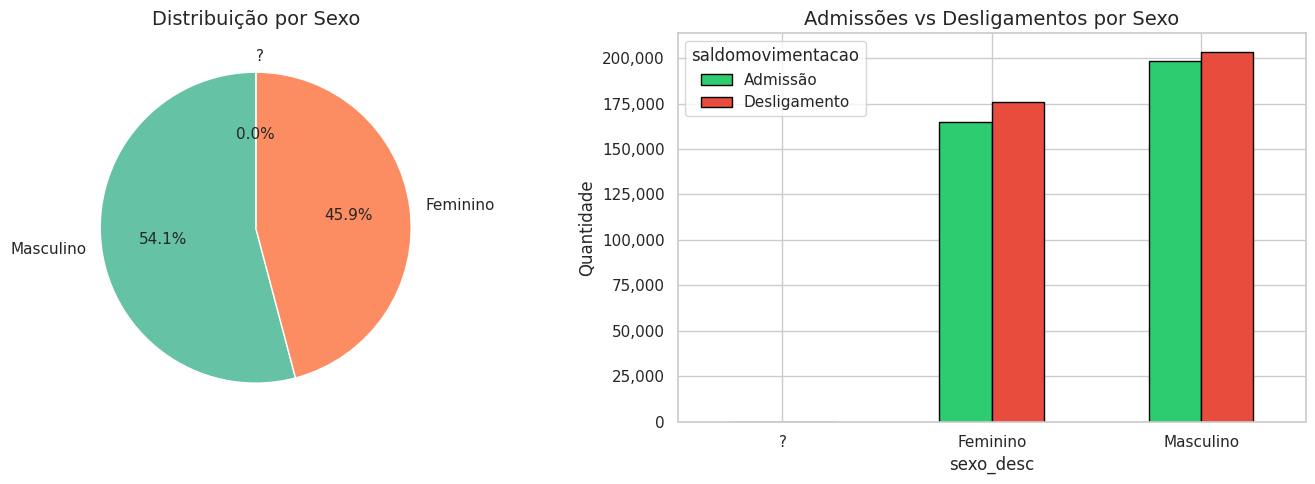

In [20]:
df["sexo_desc"] = df["sexo"].map(MAP_SEXO).fillna("?")

sexo_saldo = (
    df.groupby(["sexo_desc", "saldomovimentacao"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=MAP_SALDO)
)
sexo_saldo["Saldo"] = sexo_saldo.get("Admissão", 0) - sexo_saldo.get("Desligamento", 0)
display(sexo_saldo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["sexo_desc"].value_counts().plot.pie(
    ax=axes[0], autopct="%1.1f%%", startangle=90,
    colors=sns.color_palette("Set2"),
    textprops={"fontsize": 11},
)
axes[0].set_ylabel("")
axes[0].set_title("Distribuição por Sexo")

sexo_saldo[["Admissão", "Desligamento"]].plot.bar(
    ax=axes[1], color=["#2ecc71", "#e74c3c"], edgecolor="black",
)
axes[1].set_title("Admissões vs Desligamentos por Sexo")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylabel("Quantidade")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

### 8.2 Raça/Cor

saldomovimentacao,Desligamento,Admissão,Saldo
raca_desc,,,
Amarela,2962,2775,-187
Branca,222508,216995,-5513
Indígena,888,1433,545
Não informada,21566,7149,-14417
Parda,111474,115394,3920
Preta,19548,19735,187


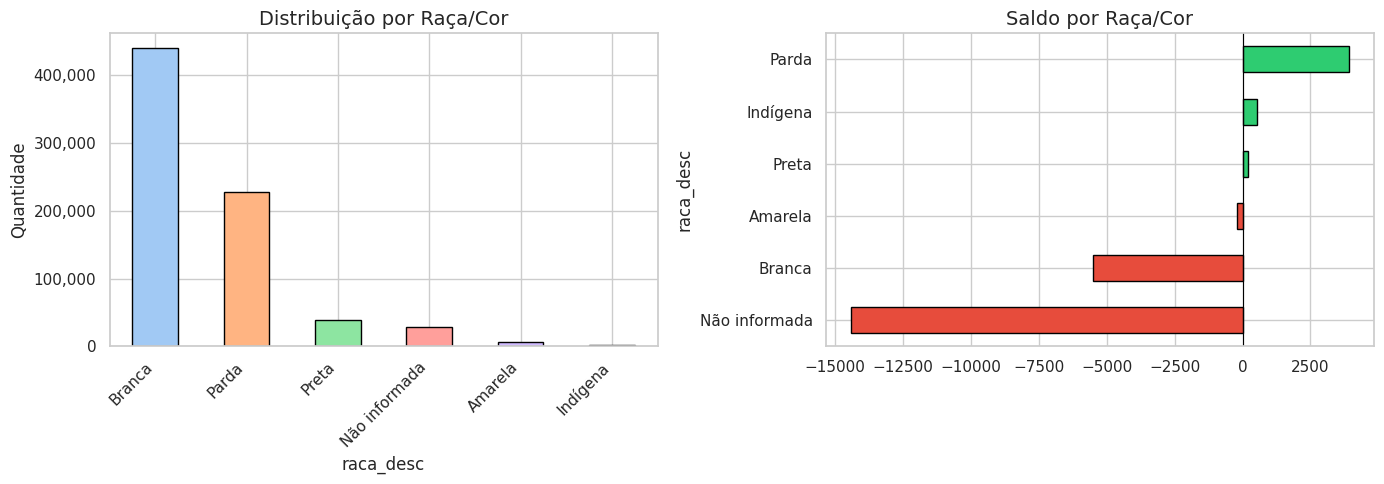

In [21]:
df["raca_desc"] = df["racacor"].map(MAP_RACA_COR).fillna("?")

raca_saldo = (
    df.groupby(["raca_desc", "saldomovimentacao"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=MAP_SALDO)
)
raca_saldo["Saldo"] = raca_saldo.get("Admissão", 0) - raca_saldo.get("Desligamento", 0)
display(raca_saldo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["raca_desc"].value_counts().plot.bar(
    ax=axes[0], color=sns.color_palette("pastel"), edgecolor="black",
)
axes[0].set_title("Distribuição por Raça/Cor")
axes[0].set_ylabel("Quantidade")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

raca_saldo["Saldo"].sort_values().plot.barh(
    ax=axes[1], color=["#e74c3c" if v < 0 else "#2ecc71" for v in raca_saldo["Saldo"].sort_values()],
    edgecolor="black",
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Saldo por Raça/Cor")

plt.tight_layout()
plt.show()

### 8.3 Grau de Instrução

saldomovimentacao,Desligamento,Admissão,Saldo
instrucao_desc,,,
Analfabeto,1226,1334,108
Até 5ª inc.,4309,4046,-263
5ª completa,3423,3134,-289
6ª-9ª inc.,11354,10827,-527
Fund. Completo,28588,28280,-308
Médio Inc.,25203,23634,-1569
Médio Completo,247485,241455,-6030
Superior Inc.,18812,17917,-895
Superior Completo,33448,29073,-4375


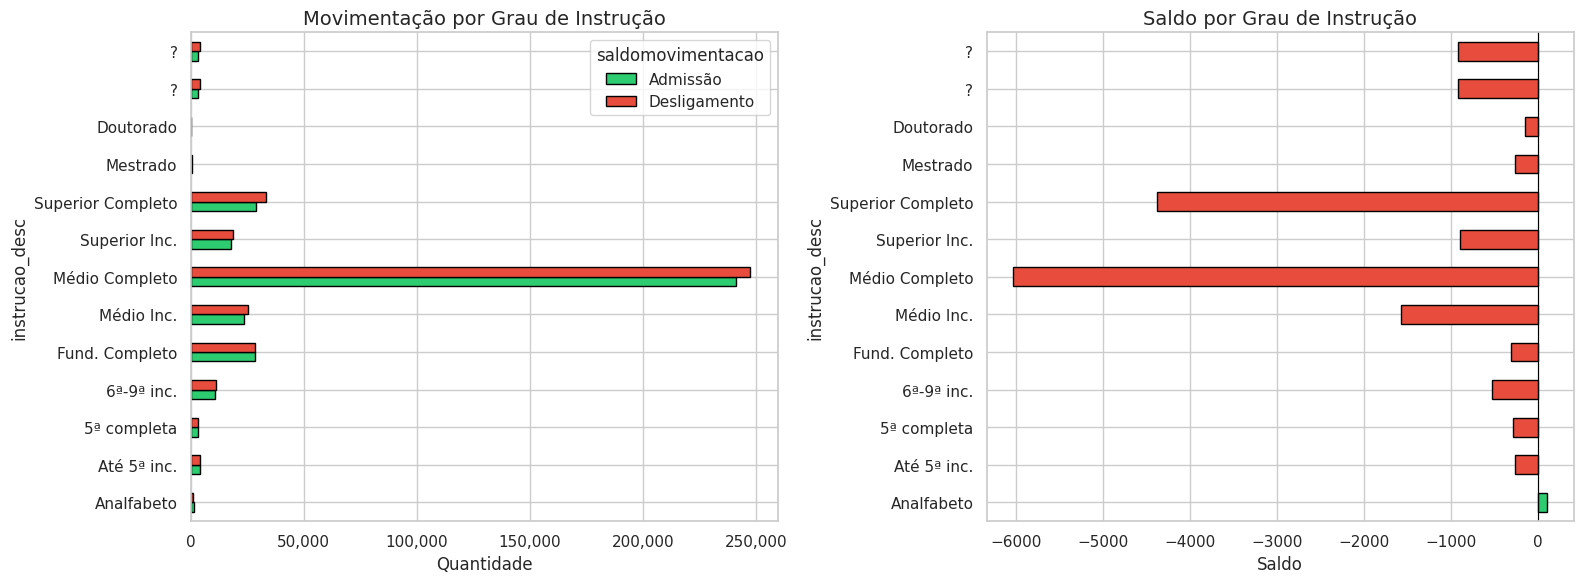

In [22]:
df["instrucao_desc"] = df["graudeinstrucao"].map(MAP_GRAU_INSTRUCAO).fillna("?")

# Ordenar por código para manter hierarquia
ordem_instrucao = (
    df[["graudeinstrucao", "instrucao_desc"]]
    .drop_duplicates()
    .sort_values("graudeinstrucao")["instrucao_desc"]
    .tolist()
)

instr_saldo = (
    df.groupby(["instrucao_desc", "saldomovimentacao"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=MAP_SALDO)
    .reindex(ordem_instrucao)
)
instr_saldo["Saldo"] = instr_saldo.get("Admissão", 0) - instr_saldo.get("Desligamento", 0)
display(instr_saldo)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

instr_saldo[["Admissão", "Desligamento"]].plot.barh(
    ax=axes[0], color=["#2ecc71", "#e74c3c"], edgecolor="black",
)
axes[0].set_title("Movimentação por Grau de Instrução")
axes[0].set_xlabel("Quantidade")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

instr_saldo["Saldo"].plot.barh(
    ax=axes[1],
    color=["#e74c3c" if v < 0 else "#2ecc71" for v in instr_saldo["Saldo"]],
    edgecolor="black",
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Saldo por Grau de Instrução")
axes[1].set_xlabel("Saldo")

plt.tight_layout()
plt.show()

---

---

---

### 8.4 Idade

Estatísticas de idade:


,count,mean,std,min,25%,50%,75%,max
idade,742424.00,33.10,11.51,14.00,24.00,31.00,41.00,97.00


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

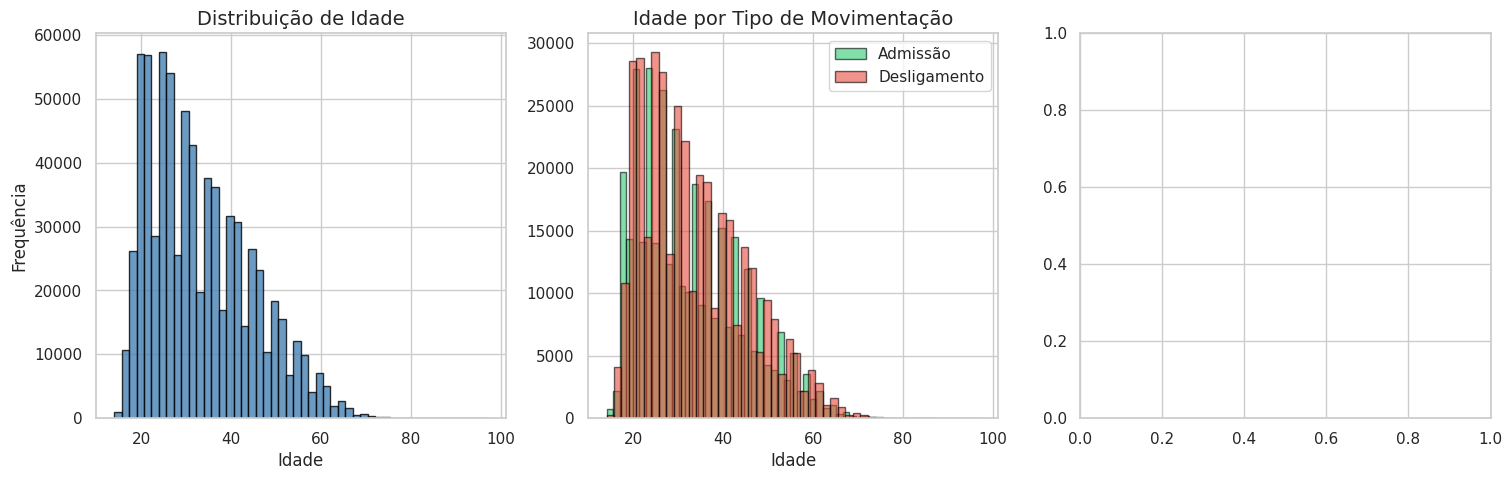

In [23]:
print("Estatísticas de idade:")
display(df["idade"].describe().to_frame().T)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma geral
df["idade"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Distribuição de Idade")
axes[0].set_xlabel("Idade")
axes[0].set_ylabel("Frequência")

# Por tipo de movimentação
for saldo_val, label, cor in [(1, "Admissão", "#2ecc71"), (-1, "Desligamento", "#e74c3c")]:
    df.loc[df["saldomovimentacao"] == saldo_val, "idade"].hist(
        bins=50, ax=axes[1], alpha=0.6, label=label, color=cor, edgecolor="black",
    )
axes[1].set_title("Idade por Tipo de Movimentação")
axes[1].set_xlabel("Idade")
axes[1].legend()

# Box-plot por saldo
df.boxplot(column="idade", by=df["saldomovimentacao"].map(MAP_SALDO), ax=axes[2])
axes[2].set_title("Idade × Tipo de Movimentação")
axes[2].set_xlabel("")
axes[2].set_ylabel("Idade")
plt.suptitle("")  # remove título automático do boxplot

plt.tight_layout()
plt.show()

# Faixas etárias
bins_idade = [0, 18, 25, 35, 45, 55, 65, 200]
labels_idade = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df["faixa_etaria"] = pd.cut(df["idade"], bins=bins_idade, labels=labels_idade, right=False)

fx_counts = df.groupby(["faixa_etaria", "saldomovimentacao"], observed=True).size().unstack(fill_value=0).rename(columns=MAP_SALDO)
fx_counts["Saldo"] = fx_counts.get("Admissão", 0) - fx_counts.get("Desligamento", 0)
display(fx_counts)

NameError: name 'fx_counts' is not defined

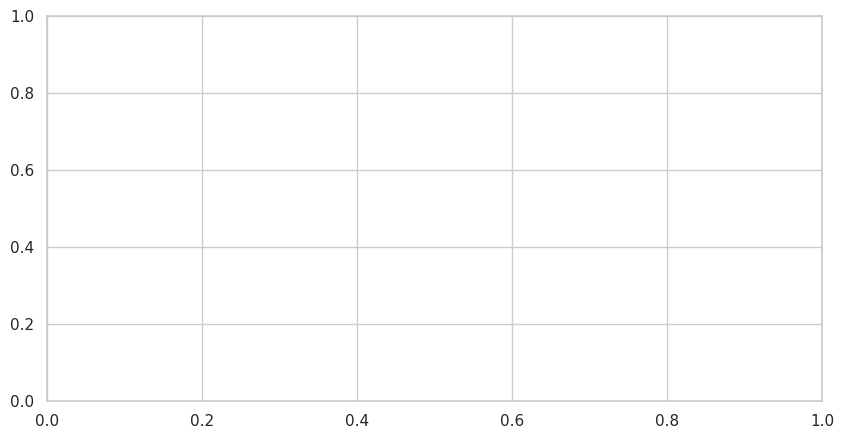

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
fx_counts[["Admissão", "Desligamento"]].plot.bar(
    ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="black", width=0.7,
)
ax.set_title("Movimentação por Faixa Etária")
ax.set_xlabel("Faixa Etária")
ax.set_ylabel("Quantidade")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 9. Análise Salarial

Estatísticas do salário:


,count,mean,std,min,25%,50%,75%,max
salario,742427.00,2319.34,5752.43,0.00,1685.25,1928.00,2300.00,1229200.00


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

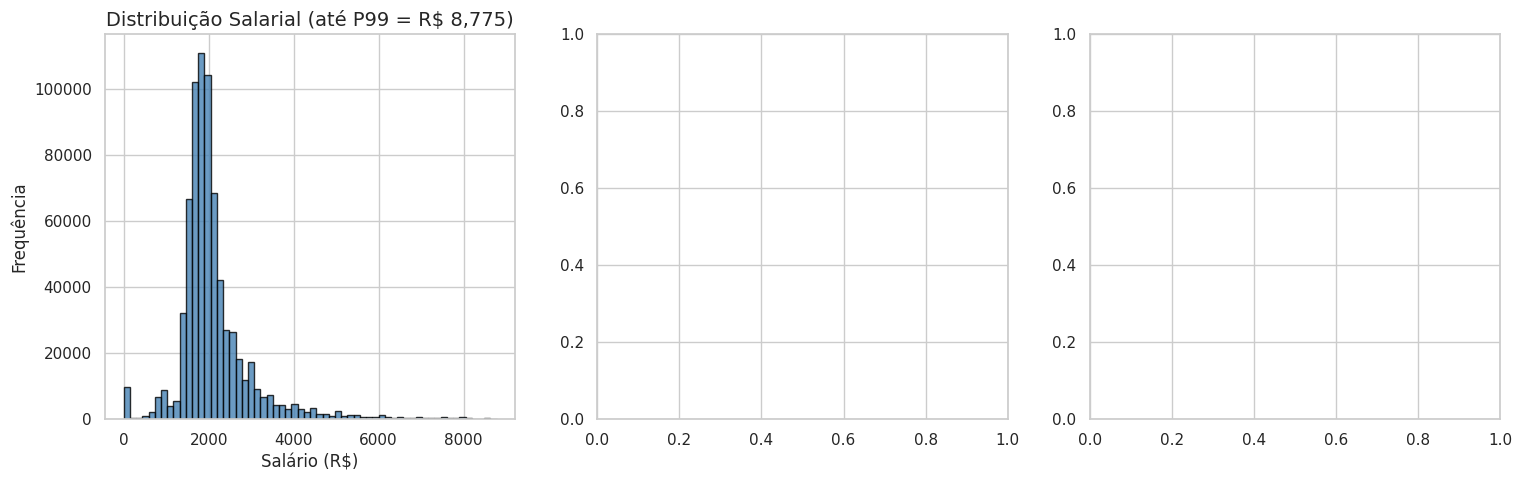

In [25]:
print("Estatísticas do salário:")
display(df["salario"].describe().to_frame().T)

# Filtrar outliers extremos para visualização (até P99)
p99 = df["salario"].quantile(0.99)
df_sal_viz = df[df["salario"].between(0, p99, inclusive="both")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_sal_viz["salario"].hist(bins=60, ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title(f"Distribuição Salarial (até P99 = R$ {p99:,.0f})")
axes[0].set_xlabel("Salário (R$)")
axes[0].set_ylabel("Frequência")

df_sal_viz.boxplot(column="salario", by=df_sal_viz["saldomovimentacao"].map(MAP_SALDO), ax=axes[1])
axes[1].set_title("Salário × Tipo de Movimentação")
axes[1].set_xlabel("")
axes[1].set_ylabel("Salário (R$)")
plt.suptitle("")

# Salário por sexo (box)
df_sal_viz.boxplot(column="salario", by=df_sal_viz["sexo_desc"], ax=axes[2])
axes[2].set_title("Salário × Sexo")
axes[2].set_xlabel("")
axes[2].set_ylabel("Salário (R$)")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [6]:
# Salário médio por grau de instrução
sal_instrucao = df.groupby("instrucao_desc")["salario"].agg(["mean", "median", "count"])
sal_instrucao.columns = ["Média", "Mediana", "N"]
sal_instrucao = sal_instrucao.reindex(ordem_instrucao)
display(sal_instrucao)

fig, ax = plt.subplots(figsize=(12, 6))
sal_instrucao[["Média", "Mediana"]].plot.barh(ax=ax, edgecolor="black")
ax.set_title("Salário Médio e Mediano por Grau de Instrução")
ax.set_xlabel("R$")
plt.tight_layout()
plt.show()

KeyError: 'instrucao_desc'

In [ ]:
# Salário médio por seção CNAE (top 10 maiores salários)
sal_secao = df.groupby("secao_desc")["salario"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
sal_secao.columns = ["Média", "Mediana", "N"]
display(sal_secao)

fig, ax = plt.subplots(figsize=(12, 7))
sal_secao["Média"].sort_values().plot.barh(ax=ax, color="teal", edgecolor="black")
ax.set_title("Salário Médio por Seção CNAE")
ax.set_xlabel("R$")
plt.tight_layout()
plt.show()

In [ ]:
# Análise: salário zero ou negativo
n_sal_zero = (df["salario"] == 0).sum()
n_sal_neg = (df["salario"] < 0).sum()
print(f"Registros com salário = 0: {n_sal_zero:,} ({n_sal_zero/len(df)*100:.2f}%)")
print(f"Registros com salário < 0: {n_sal_neg:,} ({n_sal_neg/len(df)*100:.2f}%)")

# Unidade salarial
df["unid_salario_desc"] = df["unidadesalariocodigo"].map(MAP_UNID_SALARIO).fillna("?")
print("\nDistribuição por unidade salarial:")
display(df["unid_salario_desc"].value_counts().to_frame("contagem"))

## 10. Variáveis de Trabalho

### 10.1 Horas contratuais

In [ ]:
print("Estatísticas de horas contratuais:")
display(df["horascontratuais"].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["horascontratuais"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Distribuição de Horas Contratuais")
axes[0].set_xlabel("Horas/semana")
axes[0].set_ylabel("Frequência")

top_horas = df["horascontratuais"].value_counts().head(10)
top_horas.plot.bar(ax=axes[1], color="teal", edgecolor="black")
axes[1].set_title("Top 10 Jornadas Mais Frequentes")
axes[1].set_xlabel("Horas/semana")
axes[1].set_ylabel("Frequência")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

### 10.2 Tamanho do Estabelecimento

In [ ]:
df["tam_estab_desc"] = df["tamestabjan"].map(MAP_TAM_ESTAB).fillna("?")

tam_saldo = (
    df.groupby(["tam_estab_desc", "saldomovimentacao"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=MAP_SALDO)
)
tam_saldo["Saldo"] = tam_saldo.get("Admissão", 0) - tam_saldo.get("Desligamento", 0)
display(tam_saldo)

fig, ax = plt.subplots(figsize=(10, 5))
tam_saldo[["Admissão", "Desligamento"]].plot.bar(
    ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="black",
)
ax.set_title("Movimentação por Tamanho do Estabelecimento")
ax.set_ylabel("Quantidade")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

### 10.3 Tipo de Empregador e Estabelecimento

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["tipoempregador"].map(MAP_TIPO_EMPREGADOR).fillna("?").value_counts().plot.bar(
    ax=axes[0], color="steelblue", edgecolor="black",
)
axes[0].set_title("Tipo de Empregador")
axes[0].set_ylabel("Quantidade")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

df["tipoestabelecimento"].map(MAP_TIPO_ESTABELECIMENTO).fillna("?").value_counts().plot.bar(
    ax=axes[1], color="teal", edgecolor="black",
)
axes[1].set_title("Tipo de Estabelecimento")
axes[1].set_ylabel("Quantidade")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

### 10.4 Trabalho Intermitente, Parcial, Aprendiz e Deficiência

In [ ]:
flags = {
    "indtrabintermitente": "Trabalho Intermitente",
    "indtrabparcial": "Trabalho Parcial",
    "indicadoraprendiz": "Aprendiz",
}

resumo_flags = []
for col, desc in flags.items():
    n_sim = (df[col] == 1).sum()
    pct = n_sim / len(df) * 100
    resumo_flags.append({"Variável": desc, "Sim (=1)": n_sim, "%": round(pct, 2)})

n_def = (df["tipodedeficiencia"] != 0).sum()
pct_def = n_def / len(df) * 100
resumo_flags.append({"Variável": "Possui Deficiência", "Sim (=1)": n_def, "%": round(pct_def, 2)})

display(pd.DataFrame(resumo_flags))

# Deficiência detalhada
def_counts = df["tipodedeficiencia"].map(MAP_DEFICIENCIA).fillna("?").value_counts()
print("\nDetalhamento de deficiências:")
display(def_counts.to_frame("contagem"))

### 10.5 Categoria do Vínculo

In [ ]:
cat_counts = df["categoria"].value_counts().head(15)
print("Top 15 categorias de vínculo:")
display(cat_counts.to_frame("contagem"))

fig, ax = plt.subplots(figsize=(10, 5))
cat_counts.plot.bar(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Top 15 Categorias de Vínculo")
ax.set_xlabel("Categoria")
ax.set_ylabel("Quantidade")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

### 10.6 Ocupações mais frequentes (CBO)

In [ ]:
cbo_counts = df["cbo2002ocupacao"].value_counts().head(20)
print(f"Total de ocupações distintas (CBO): {df['cbo2002ocupacao'].nunique():,}")
print("\nTop 20 ocupações:")
display(cbo_counts.to_frame("contagem"))

fig, ax = plt.subplots(figsize=(12, 6))
cbo_counts.plot.bar(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Top 20 Ocupações (CBO 2002)")
ax.set_xlabel("Código CBO")
ax.set_ylabel("Quantidade")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. Matriz de Correlação

In [ ]:
colunas_corr = [
    "saldomovimentacao", "idade", "horascontratuais", "salario",
    "valorsalariofixo", "graudeinstrucao", "racacor", "sexo",
    "tamestabjan", "indtrabintermitente", "indtrabparcial",
    "indicadoraprendiz", "tipodedeficiencia", "tipoempregador",
]

corr = df[colunas_corr].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
    annot_kws={"size": 9},
)
ax.set_title("Matriz de Correlação (variáveis numéricas)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Correlações com a variável-alvo (ordenadas)
corr_target = corr["saldomovimentacao"].drop("saldomovimentacao").sort_values(key=abs, ascending=False)
print("Correlação com saldomovimentacao (em módulo):")
display(corr_target.to_frame("correlação"))

fig, ax = plt.subplots(figsize=(10, 6))
corr_target.sort_values().plot.barh(
    ax=ax, color=["#e74c3c" if v < 0 else "#2ecc71" for v in corr_target.sort_values()],
    edgecolor="black",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação com saldomovimentacao")
ax.set_xlabel("Coeficiente de Pearson")
plt.tight_layout()
plt.show()

## 12. Análise Bivariada com a Variável-Alvo

In [ ]:
# Taxa de admissão por variáveis categóricas
df["admissao"] = (df["saldomovimentacao"] == 1).astype(int)

variaveis_cat = [
    ("sexo_desc", "Sexo"),
    ("raca_desc", "Raça/Cor"),
    ("instrucao_desc", "Escolaridade"),
    ("faixa_etaria", "Faixa Etária"),
    ("secao_desc", "Seção CNAE"),
    ("tam_estab_desc", "Tam. Estabelecimento"),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.ravel()

for idx, (col, titulo) in enumerate(variaveis_cat):
    taxa = df.groupby(col, observed=True)["admissao"].mean().sort_values() * 100
    taxa.plot.barh(ax=axes[idx], color="steelblue", edgecolor="black")
    axes[idx].set_title(f"Taxa de Admissão (%) por {titulo}")
    axes[idx].set_xlabel("%")
    axes[idx].axvline(50, color="red", linestyle="--", linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Salário médio: admitidos vs desligados, por setor
sal_saldo_secao = df.groupby(["secao_desc", "saldomovimentacao"])["salario"].mean().unstack().rename(columns=MAP_SALDO)
sal_saldo_secao = sal_saldo_secao.sort_values("Admissão", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
sal_saldo_secao.plot.barh(ax=ax, edgecolor="black", color=["#2ecc71", "#e74c3c"])
ax.set_title("Salário Médio: Admitidos vs Desligados por Seção CNAE")
ax.set_xlabel("Salário Médio (R$)")
plt.tight_layout()
plt.show()

In [ ]:
# Evolução temporal do target: taxa de admissão por mês
taxa_adm_tempo = df.groupby("competenciamov")["admissao"].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
taxa_adm_tempo.plot(ax=ax, marker="o", linewidth=2, color="steelblue")
ax.axhline(50, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_title("Taxa de Admissão (%) por Competência")
ax.set_xlabel("Competência")
ax.set_ylabel("%")
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 14. Conclusões e Insights

Resumo dos principais achados desta análise exploratória:

**Qualidade dos dados:**
- Verificar percentual de valores ausentes e duplicatas identificados acima.
- A coluna `horascontratuais` pode conter valores com vírgula como separador decimal.
- Checar valores inesperados em variáveis categóricas.

**Variável-alvo (`saldomovimentacao`):**
- O target é binário (1 = admissão, -1 = desligamento). Avaliar o desbalanceamento entre as classes.

**Padrões temporais:**
- O volume de movimentação varia significativamente entre competências.
- Os meses recomendados (nov, dez, jan) devem ser priorizados; os demais servem como contexto.

**Perfil demográfico:**
- Analisar diferenças de taxa de admissão entre sexo, raça/cor, faixa etária e escolaridade.
- O salário médio varia conforme grau de instrução e setor econômico.

**Para a modelagem:**
- Alta cardinalidade em `cbo2002ocupacao`, `subclasse` e `municipio` — considerar agrupamentos.
- Variáveis binárias com baixa frequência de 1 (intermitente, parcial, aprendiz, deficiência) podem ter pouco poder preditivo individual.
- A correlação linear com o target tende a ser baixa, sinalizando a necessidade de modelos não-lineares.
- Verificar a distribuição do dataset de teste para garantir compatibilidade com o treino.